In [1]:
import pandas as pd
#from openai import OpenAI
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import time, datetime
from sklearn.metrics.pairwise import cosine_similarity
import scipy.stats as stats
import ast

In [17]:
DIM = 256
print('get data from csv')
df = pd.read_csv('stored_embeddings_significant/selected_pairs_df_005_256.csv')
df['embedding_1'] = df['embedding_1'].apply(ast.literal_eval)
df['embedding_2'] = df['embedding_2'].apply(ast.literal_eval)

get data from csv


In [11]:
df_half_1 = df[['CTR_1', 'embedding_1']].rename(columns={'CTR_1': 'CTR', 'embedding_1': 'embedding'})
df_half_2 = df[['CTR_2', 'embedding_2']].rename(columns={'CTR_2': 'CTR', 'embedding_2': 'embedding'})

# Concatenating the two halves
new_df = pd.concat([df_half_1, df_half_2]).reset_index(drop=True)
df_ctr = new_df.drop_duplicates(subset=['CTR']).reset_index(drop=True)
del df_half_1, df_half_2, new_df

In [12]:
from sklearn.model_selection import train_test_split

# predict the winner
embed = torch.tensor(np.array(df_ctr['embedding'].tolist())).to(torch.float32)
target = torch.tensor(df_ctr['CTR'].values).to(torch.float32) # 0 for headline_1, 1 for headline_2

# split the data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(embed, target, test_size=0.2, random_state=42)


# train a simple linear model
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#clf = LinearRegression().fit(X_train, y_train)
clf = HuberRegressor(epsilon = 1, max_iter = 500).fit(X_train, y_train)
print('Linear Regression + gpt embedding Performance')
# Predict on the training set
y_train_pred = clf.predict(X_train)

# Predict on the test set
y_test_pred = clf.predict(X_test)

# Calculate metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Calculate metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print out the metrics for the training set
print(f"Training Set - Mean Squared Error: {mse_train}")
print(f"Training Set - Mean Absolute Error: {mae_train}")
print(f"Training Set - R2 Score: {r2_train}")

# Print out the metrics for the test set
print(f"Test Set - Mean Squared Error: {mse_test}")
print(f"Test Set - Mean Absolute Error: {mae_test}")
print(f"Test Set - R2 Score: {r2_test}")

Linear Regression + gpt embedding Performance
Training Set - Mean Squared Error: 0.00013107202083024766
Training Set - Mean Absolute Error: 0.007392929945971893
Training Set - R2 Score: 0.17438553330716178
Test Set - Mean Squared Error: 0.00012140987411970998
Test Set - Mean Absolute Error: 0.007278566777282057
Test Set - R2 Score: 0.1687580083919038


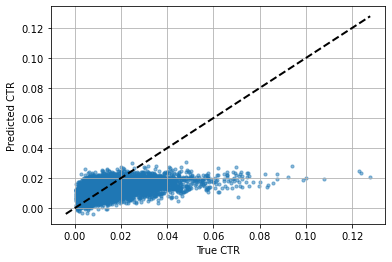

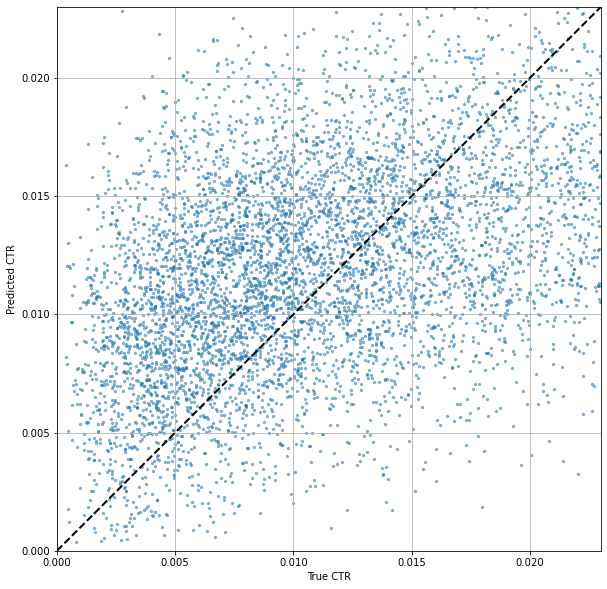

In [13]:
plt.scatter(y_test, y_test_pred, s=10, alpha=0.5)  # s controls the size of the dots

# Plot the y=x line (diagonal line)
max_value = max(y_test.max(), y_test_pred.max())  # Get the maximum value for x and y axis limits
min_value = min(y_test.min(), y_test_pred.min())  # Get the minimum value for x and y axis limits
plt.plot([min_value, max_value], [min_value, max_value], 'k--', lw=2)  # 'k--' means black dashed line, lw is line width

# Labeling the axes
plt.xlabel('True CTR')
plt.ylabel('Predicted CTR')

# Show the plot with a grid
plt.grid(True)
plt.show()

percentile_90 = np.percentile(np.hstack((y_test, y_test_pred)), 90)

# Filter out the top 10% of outliers
mask = y_test <= percentile_90
y_test_filtered = y_test[mask]
y_test_pred_filtered = y_test_pred[mask]

plt.figure(figsize=(10, 10))
plt.scatter(y_test_filtered, y_test_pred_filtered, s=5, alpha=0.5)
plt.plot([0, percentile_90], [0, percentile_90], 'k--', lw=2)

# Labeling the axes
plt.xlabel('True CTR')
plt.ylabel('Predicted CTR')

# Set the axes to be equal
plt.axis('square')

# Set the same scale for both axes
plt.xlim(0, percentile_90)
plt.ylim(0, percentile_90)

# Show the plot with a grid
plt.grid(True)
plt.show()


In [14]:
ctr_pred_1 = clf.predict(torch.tensor(np.array(df['embedding_1'].tolist())).to(torch.float32))
ctr_pred_2 = clf.predict(torch.tensor(np.array(df['embedding_2'].tolist())).to(torch.float32))
print('Accuracy = ', np.equal((ctr_pred_1 <= ctr_pred_2) + 1, df['higher_CTR']).mean())

Accuracy =  0.7369886102456714
